# Customer Segmentation in the Retail Industry Using Machine Learning and Consumer Behaviour Analysis

## Chapter 4: Results - Customer Segmentation

This Jupyter Notebook presents the statistical and machine learning analysis used to identify customer segments based on consumer behaviour. The analysis follows the structure of Chapter 4 of the accompanying report.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 4.1 Frequencies Distribution and Descriptive Statistics

This section presents the frequency distributions and descriptive statistics of the questionnaire responses. The analysis includes demographic characteristics and the four main behavioural constructs: Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety.

In [2]:
# Load the Excel dataset

from pathlib import Path

possible_paths = [
    "/content/working sheet new.xlsx",
    "working sheet new.xlsx",
    "/mnt/data/working sheet new.xlsx"
]

file_path = next((p for p in possible_paths if Path(p).exists()), None)
if file_path is None:
    raise FileNotFoundError("working sheet new.xlsx was not found. Upload the Excel workbook to the notebook environment.")

excel_file = pd.ExcelFile(file_path)

print("Using file:", file_path)
print("Available sheets:")
print(excel_file.sheet_names)

Using file: /content/working sheet new.xlsx
Available sheets:
['Form Responses 1', 'coded file', 'codes']


In [3]:
# Read the original categorical responses and the manually coded numerical data

raw_data = pd.read_excel(
    file_path,
    sheet_name="Form Responses 1"
)

coded_raw_data = pd.read_excel(
    file_path,
    sheet_name="coded file"
)

print("Categorical dataset shape:", raw_data.shape)
print("Coded numerical dataset shape:", coded_raw_data.shape)

Categorical dataset shape: (216, 27)
Coded numerical dataset shape: (216, 26)


In [4]:
# Display the first rows of the original categorical dataset

raw_data.head()

,Timestamp,What is your age?,What is your Gender?,What is your approximate monthly income?,What is your highest completed level of education?,What is your current employment status?,I regularly purchase products from retail stores or retail websites.,I shop for retail products several times each month.,I compare different products before making a purchase.,I usually plan my retail purchases before shopping.,...,I sometimes delay a purchase until a promotion or discount becomes available.,I regularly purchase products from different product categories.,My shopping basket usually contains several different types of products.,I am willing to try products from categories that I have not purchased before.,My retail purchases cover a wide range of personal or household needs.,Which shopping channel do you generally prefer?,Which shopping channel have you used most frequently during the past three months?,Which channel do you prefer when researching and comparing products?,Which channel do you prefer when purchasing routine or frequently used products?,Which channel do you prefer when purchasing expensive or important products?
0,2026-07-23 13:43:16.468,18-24 years,Male,"£1,000–£1,999",Master’s degree,Employed part-time,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,...,Agree,Agree,Agree,Agree,Agree,Physical retail stores,Both equally,Physical retail stores,Online shopping,Physical retail stores
1,2026-07-23 13:49:52.756,18-24 years,Male,"£4,000 or above",Doctoral degree or above,Retired,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,...,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Agree,Both equally,Both equally,Both online and physical stores,Both equally,Both equally
2,2026-07-23 14:12:51.878,18-24 years,Female,"Less than £1,000",Bachelor’s degree,Student,Strongly Agree,Agree,Agree,Agree,...,Agree,Uncertain,Strongly Agree,Agree,Agree,Both equally,Online shopping,Online channels,Online shopping,Both equally
3,2026-07-23 14:19:10.586,25-34 years,Male,"Less than £1,000",Master’s degree,Employed full-time,Agree,Agree,Agree,Agree,...,Agree,Agree,Agree,Agree,Agree,Both equally,Physical retail stores,Physical retail stores,Physical retail stores,Physical retail stores
4,2026-07-23 14:24:36.509,18-24 years,Female,Prefer not to say,Bachelor’s degree,Student,Agree,Agree,Strongly Agree,Strongly Agree,...,Uncertain,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Physical retail stores,Physical retail stores,Physical retail stores,Physical retail stores,Physical retail stores


### Data Preparation and Coding

The original questionnaire responses were imported from the `Form Responses 1` sheet. The workbook also contains a `coded file` sheet in which the questionnaire responses have already been converted to numerical codes.

The categorical dataset is retained for demographic and shopping-channel analysis, while the manually coded numerical dataset is used for the behavioural statistical analyses. Because the coded file uses the direction 1 = Strongly Agree and 5 = Strongly Disagree, the 16 behavioural items are reverse-coded in the notebook to use the conventional analytical direction 1 = Strongly Disagree and 5 = Strongly Agree.


In [5]:
# Create clean categorical and numerical datasets from the new workbook

# The original response sheet already contains the questionnaire variable names
# in the first row, with one Timestamp column that is not used in the analysis.
data = raw_data.drop(columns=["Timestamp"]).copy()

# Add a respondent ID so the dataset retains the same 27-variable structure
# used by the downstream analysis.
data.insert(0, "ID", range(1, len(data) + 1))

# The coded file contains the same 26 questionnaire variables, already
# converted to numerical codes.
numeric_data = coded_raw_data.copy()
numeric_data.insert(0, "ID", range(1, len(numeric_data) + 1))

# Confirm that the categorical and coded datasets have matching variables
assert list(data.columns) == list(numeric_data.columns), (
    "The categorical and coded datasets do not have matching columns."
)

print("Number of respondents:", data.shape[0])
print("Number of variables:", data.shape[1])
print("Coded dataset shape:", numeric_data.shape)

data.head()

Number of respondents: 216
Number of variables: 27
Coded dataset shape: (216, 27)


,ID,What is your age?,What is your Gender?,What is your approximate monthly income?,What is your highest completed level of education?,What is your current employment status?,I regularly purchase products from retail stores or retail websites.,I shop for retail products several times each month.,I compare different products before making a purchase.,I usually plan my retail purchases before shopping.,...,I sometimes delay a purchase until a promotion or discount becomes available.,I regularly purchase products from different product categories.,My shopping basket usually contains several different types of products.,I am willing to try products from categories that I have not purchased before.,My retail purchases cover a wide range of personal or household needs.,Which shopping channel do you generally prefer?,Which shopping channel have you used most frequently during the past three months?,Which channel do you prefer when researching and comparing products?,Which channel do you prefer when purchasing routine or frequently used products?,Which channel do you prefer when purchasing expensive or important products?
0,1,18-24 years,Male,"£1,000–£1,999",Master’s degree,Employed part-time,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,...,Agree,Agree,Agree,Agree,Agree,Physical retail stores,Both equally,Physical retail stores,Online shopping,Physical retail stores
1,2,18-24 years,Male,"£4,000 or above",Doctoral degree or above,Retired,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,...,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Agree,Both equally,Both equally,Both online and physical stores,Both equally,Both equally
2,3,18-24 years,Female,"Less than £1,000",Bachelor’s degree,Student,Strongly Agree,Agree,Agree,Agree,...,Agree,Uncertain,Strongly Agree,Agree,Agree,Both equally,Online shopping,Online channels,Online shopping,Both equally
3,4,25-34 years,Male,"Less than £1,000",Master’s degree,Employed full-time,Agree,Agree,Agree,Agree,...,Agree,Agree,Agree,Agree,Agree,Both equally,Physical retail stores,Physical retail stores,Physical retail stores,Physical retail stores
4,5,18-24 years,Female,Prefer not to say,Bachelor’s degree,Student,Agree,Agree,Strongly Agree,Strongly Agree,...,Uncertain,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Physical retail stores,Physical retail stores,Physical retail stores,Physical retail stores,Physical retail stores


In [6]:
# Display the behavioural question groups

print("SHOPPING BEHAVIOUR")
print(data.columns[6:10].tolist())

print("\nBRAND LOYALTY")
print(data.columns[10:14].tolist())

print("\nPROMOTIONAL SENSITIVITY")
print(data.columns[14:18].tolist())

print("\nPRODUCT CATEGORY VARIETY")
print(data.columns[18:22].tolist())

SHOPPING BEHAVIOUR
['I regularly purchase products from retail stores or retail websites.', 'I shop for retail products several times each month.', 'I compare different products before making a purchase.', 'I usually plan my retail purchases before shopping.']

BRAND LOYALTY
['I prefer to purchase products from the same retailers.', 'I prefer to purchase brands with which I am already familiar.', 'I usually choose my preferred brand even when other brands are available.', 'I intend to repurchase a brand when I am satisfied with it.']

PROMOTIONAL SENSITIVITY
['Discounts influence the products that I purchase.', 'Special offers encourage me to purchase additional products.', 'Loyalty rewards influence where I choose to shop.', 'I sometimes delay a purchase until a promotion or discount becomes available.']

PRODUCT CATEGORY VARIETY
['I regularly purchase products from different product categories.', 'My shopping basket usually contains several different types of products.', 'I am willin

In [7]:
# Define the coding used in the Excel "coded file" sheet

likert_mapping = {
    "Strongly Agree": 1,
    "Agree": 2,
    "Uncertain": 3,
    "Disagree": 4,
    "Strongly Disagree": 5
}

print(likert_mapping)
print("The coded file uses 1 = Strongly Agree and 5 = Strongly Disagree.")


{'Strongly Agree': 1, 'Agree': 2, 'Uncertain': 3, 'Disagree': 4, 'Strongly Disagree': 5}
The coded file uses 1 = Strongly Agree and 5 = Strongly Disagree.


In [8]:
# Select the 16 behavioural questionnaire items

shopping_cols = data.columns[6:10]
loyalty_cols = data.columns[10:14]
promo_cols = data.columns[14:18]
variety_cols = data.columns[18:22]

behavioural_cols = list(
    shopping_cols
) + list(
    loyalty_cols
) + list(
    promo_cols
) + list(
    variety_cols
)

print("Total behavioural questions:", len(behavioural_cols))

Total behavioural questions: 16


In [9]:
# Reverse-code the 16 behavioural questionnaire items

# The Excel coded file uses the direction:
# 1 = Strongly Agree, ..., 5 = Strongly Disagree.
# For interpretation and reporting, the analysis uses the conventional direction:
# 1 = Strongly Disagree, ..., 5 = Strongly Agree.
# Reversing is performed only for the 16 behavioural items.

numeric_data[behavioural_cols] = 6 - numeric_data[behavioural_cols].apply(pd.to_numeric)

print("Behavioural items reverse-coded to the conventional 1–5 Likert direction.")
numeric_data[behavioural_cols].head()


Behavioural items reverse-coded to the conventional 1–5 Likert direction.


,I regularly purchase products from retail stores or retail websites.,I shop for retail products several times each month.,I compare different products before making a purchase.,I usually plan my retail purchases before shopping.,I prefer to purchase products from the same retailers.,I prefer to purchase brands with which I am already familiar.,I usually choose my preferred brand even when other brands are available.,I intend to repurchase a brand when I am satisfied with it.,Discounts influence the products that I purchase.,Special offers encourage me to purchase additional products.,Loyalty rewards influence where I choose to shop.,I sometimes delay a purchase until a promotion or discount becomes available.,I regularly purchase products from different product categories.,My shopping basket usually contains several different types of products.,I am willing to try products from categories that I have not purchased before.,My retail purchases cover a wide range of personal or household needs.
0,5,5,5,5,3,4,4,4,4,5,4,4,4,4,4,4
1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,4
2,5,4,4,4,4,4,4,4,4,5,4,4,3,5,4,4
3,4,4,4,4,4,4,4,4,3,3,4,4,4,4,4,4
4,4,4,5,5,3,5,5,5,5,5,5,3,4,5,5,5


In [10]:
# Check the manually coded behavioural responses

for column in behavioural_cols:
    invalid_values = numeric_data[column].isna().sum()
    non_numeric = pd.to_numeric(numeric_data[column], errors="coerce").isna().sum() - invalid_values

    if invalid_values > 0:
        print(f"{column}: {invalid_values} missing values")
    if non_numeric > 0:
        print(f"{column}: {non_numeric} non-numeric values")

print("Coded-data validation completed.")

Coded-data validation completed.


### Construction of Behavioural Measures

The 16 behavioural questionnaire items were grouped into four consumer behaviour constructs: Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety. A composite score for each construct was calculated as the mean of its four corresponding questionnaire items.

In [11]:
# Calculate composite scores for the four behavioural constructs

numeric_data["Shopping_Behavior"] = numeric_data[shopping_cols].mean(axis=1)

numeric_data["Brand_Loyalty"] = numeric_data[loyalty_cols].mean(axis=1)

numeric_data["Promo_Senstivity"] = numeric_data[promo_cols].mean(axis=1)

numeric_data["Product_Variety"] = numeric_data[variety_cols].mean(axis=1)

# Display the four behavioural measures
numeric_data[
    [
        "Shopping_Behavior",
        "Brand_Loyalty",
        "Promo_Senstivity",
        "Product_Variety"
    ]
].head()

,Shopping_Behavior,Brand_Loyalty,Promo_Senstivity,Product_Variety
0,5.00,3.75,4.25,4.00
1,5.00,5.00,5.00,4.50
2,4.25,4.00,4.25,4.00
3,4.00,4.00,3.50,4.00
4,4.50,4.50,4.50,4.75


In [12]:
# Descriptive statistics for the four behavioural constructs

behavioural_measures = [
    "Shopping_Behavior",
    "Brand_Loyalty",
    "Promo_Senstivity",
    "Product_Variety"
]

descriptive_stats = numeric_data[behavioural_measures].describe().T

descriptive_stats[["count", "min", "max", "mean", "std"]]

,count,min,max,mean,std
Shopping_Behavior,216.0,1.0,5.0,3.937500,0.627958
Brand_Loyalty,216.0,1.0,5.0,3.868056,0.634253
Promo_Senstivity,216.0,1.0,5.0,3.872685,0.628301
Product_Variety,216.0,1.0,5.0,3.819444,0.614111


In [13]:
# Display the demographic variable names

print("Age:", data.columns[1])
print("Gender:", data.columns[2])
print("Income:", data.columns[3])
print("Education:", data.columns[4])
print("Employment:", data.columns[5])

Age: What is your age?
Gender: What is your Gender?
Income:   What is your approximate monthly income?  
Education: What is your highest completed level of education?
Employment: What is your current employment status?


In [14]:
# Function to generate frequency and percentage tables

def frequency_table(df, column):
    frequency = df[column].value_counts(dropna=False)
    percentage = df[column].value_counts(
        normalize=True,
        dropna=False
    ) * 100

    result = pd.DataFrame({
        "Frequency": frequency,
        "Percentage": percentage.round(1)
    })

    return result

In [15]:
# Age frequency distribution

frequency_table(data, data.columns[1])

,Frequency,Percentage
What is your age?,,
18-24 years,139,64.4
25-34 years,68,31.5
35-44 years,6,2.8
55 years or above,2,0.9
45-54 years,1,0.5


In [16]:
# Gender frequency distribution

frequency_table(data, data.columns[2])

,Frequency,Percentage
What is your Gender?,,
Male,118,54.6
Female,98,45.4


In [17]:
# Monthly income frequency distribution

frequency_table(data, data.columns[3])

,Frequency,Percentage
What is your approximate monthly income?,,
"Less than £1,000",88,40.7
Prefer not to say,69,31.9
"£1,000–£1,999",28,13.0
"£2,000–£2,999",16,7.4
"£4,000 or above",11,5.1
"£3,000–£3,999",4,1.9


In [18]:
# Education level frequency distribution

frequency_table(data, data.columns[4])

,Frequency,Percentage
What is your highest completed level of education?,,
Bachelor’s degree,102,47.2
Master’s degree,50,23.1
College or diploma,30,13.9
Secondary school or below,29,13.4
Doctoral degree or above,5,2.3


In [19]:
# Employment status frequency distribution

frequency_table(data, data.columns[5])

,Frequency,Percentage
What is your current employment status?,,
Student,79,36.6
Employed full-time,69,31.9
Employed part-time,26,12.0
Unemployed,21,9.7
Self-employed,18,8.3
Retired,3,1.4


### 4.1.2 Descriptive Statistics of Behavioural Constructs

Descriptive statistics were calculated for the four behavioural constructs: Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety. The analysis includes the number of valid observations, minimum and maximum values, mean, and standard deviation.

In [20]:
# Descriptive statistics for the four behavioural constructs

descriptive_table = numeric_data[behavioural_measures].agg(
    ['count', 'min', 'max', 'mean', 'std']
).T

# Rename the columns to match the report terminology
descriptive_table.columns = [
    'N',
    'Minimum',
    'Maximum',
    'Mean',
    'Std. Deviation'
]

# Round the results
descriptive_table = descriptive_table.round(4)

descriptive_table

,N,Minimum,Maximum,Mean,Std. Deviation
Shopping_Behavior,216.0,1.0,5.0,3.9375,0.6280
Brand_Loyalty,216.0,1.0,5.0,3.8681,0.6343
Promo_Senstivity,216.0,1.0,5.0,3.8727,0.6283
Product_Variety,216.0,1.0,5.0,3.8194,0.6141


## 4.2 Reliability Analysis

Cronbach's Alpha was used to assess the internal consistency of the questionnaire items within each behavioural construct. Reliability was assessed separately for Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety.

### 4.2.1 Cronbach's Alpha

In [21]:
# Function to calculate Cronbach's Alpha

def cronbach_alpha(df):
    """
    Calculate Cronbach's Alpha for a set of questionnaire items.
    """
    df = df.dropna()

    item_variances = df.var(axis=0, ddof=1)
    total_score = df.sum(axis=1)
    total_variance = total_score.var(ddof=1)

    n_items = df.shape[1]

    alpha = (n_items / (n_items - 1)) * (
        1 - item_variances.sum() / total_variance
    )

    return alpha

In [22]:
# Calculate Cronbach's Alpha for each behavioural construct

reliability_results = {
    "Shopping Behavior": cronbach_alpha(numeric_data[shopping_cols]),
    "Brand Loyalty": cronbach_alpha(numeric_data[loyalty_cols]),
    "Promotional Sensitivity": cronbach_alpha(numeric_data[promo_cols]),
    "Product Variety": cronbach_alpha(numeric_data[variety_cols])
}

reliability_table = pd.DataFrame(
    reliability_results.items(),
    columns=["Construct", "Cronbach's Alpha"]
)

reliability_table["Cronbach's Alpha"] = reliability_table[
    "Cronbach's Alpha"
].round(3)

reliability_table

,Construct,Cronbach's Alpha
0,Shopping Behavior,0.743
1,Brand Loyalty,0.752
2,Promotional Sensitivity,0.704
3,Product Variety,0.761


## 4.3 Correlation Analysis

Pearson's correlation analysis was conducted to examine the relationships between Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety. The strength and direction of the relationships were assessed using Pearson's correlation coefficient (r), together with the corresponding significance levels.

### 4.3.1 Pearson Correlation Matrix

In [23]:
# Calculate Pearson correlation coefficients

correlation_matrix = numeric_data[behavioural_measures].corr(
    method="pearson"
)

correlation_matrix.round(3)

,Shopping_Behavior,Brand_Loyalty,Promo_Senstivity,Product_Variety
Shopping_Behavior,1.000,0.568,0.557,0.385
Brand_Loyalty,0.568,1.000,0.594,0.383
Promo_Senstivity,0.557,0.594,1.000,0.424
Product_Variety,0.385,0.383,0.424,1.000


In [24]:
correlation_results = []

for i in range(len(behavioural_measures)):
    for j in range(i + 1, len(behavioural_measures)):

        var1 = behavioural_measures[i]
        var2 = behavioural_measures[j]

        r, p = stats.pearsonr(
            numeric_data[var1],
            numeric_data[var2]
        )

        correlation_results.append({
            "Variable 1": var1,
            "Variable 2": var2,
            "Pearson r": r,
            "p-value": p
        })

correlation_results_df = pd.DataFrame(correlation_results)

correlation_results_df["Pearson r"] = correlation_results_df["Pearson r"].round(3)
correlation_results_df["p-value"] = correlation_results_df["p-value"].round(4)

correlation_results_df

,Variable 1,Variable 2,Pearson r,p-value
0,Shopping_Behavior,Brand_Loyalty,0.568,0.0
1,Shopping_Behavior,Promo_Senstivity,0.557,0.0
2,Shopping_Behavior,Product_Variety,0.385,0.0
3,Brand_Loyalty,Promo_Senstivity,0.594,0.0
4,Brand_Loyalty,Product_Variety,0.383,0.0
5,Promo_Senstivity,Product_Variety,0.424,0.0


## 4.4 Principal Component Analysis

Principal Component Analysis (PCA) was conducted on the 16 behavioural questionnaire items to identify underlying components and reduce the dimensionality of the behavioural measures. The suitability of the data for PCA was assessed using the Kaiser-Meyer-Olkin (KMO) measure of sampling adequacy and Bartlett's Test of Sphericity.

### 4.4.1 Assessment of Data Suitability for PCA

In [25]:
# Select the 16 behavioural questionnaire items for PCA

pca_data = numeric_data[behavioural_cols].copy()

print("PCA dataset shape:", pca_data.shape)

PCA dataset shape: (216, 16)


In [26]:
# Calculate the Kaiser-Meyer-Olkin (KMO) measure

R = pca_data.corr().to_numpy()
R_inv = np.linalg.inv(R)
partial_corr = -R_inv / np.sqrt(np.outer(np.diag(R_inv), np.diag(R_inv)))
np.fill_diagonal(partial_corr, 0)
np.fill_diagonal(R, 0)

kmo_overall = (R**2).sum() / ((R**2).sum() + (partial_corr**2).sum())

print("Overall KMO:", round(kmo_overall, 3))

Overall KMO: 0.849


In [27]:
# Calculate Bartlett's Test of Sphericity

R_full = pca_data.corr().to_numpy()
n = pca_data.shape[0]
p = pca_data.shape[1]
chi_square_value = -(n - 1 - (2 * p + 5) / 6) * np.log(np.linalg.det(R_full))
degrees_of_freedom = p * (p - 1) // 2
p_value = stats.chi2.sf(chi_square_value, degrees_of_freedom)

print("Bartlett's Test")
print("Chi-square:", round(chi_square_value, 3))
print("Degrees of freedom:", degrees_of_freedom)
print("p-value:", "<0.001" if p_value < 0.001 else round(p_value, 3))

Bartlett's Test
Chi-square: 1179.879
Degrees of freedom: 120
p-value: <0.001


### 4.4.2 PCA Extraction and Explained Variance

Principal Component Analysis was performed on the 16 behavioural questionnaire items. Components were examined based on their eigenvalues and the proportion of variance explained. Components with eigenvalues greater than 1 were considered for retention.

In [28]:
# Standardize the 16 behavioural questionnaire items

scaler = StandardScaler()

pca_scaled = scaler.fit_transform(pca_data)

print("Standardized PCA data shape:", pca_scaled.shape)

Standardized PCA data shape: (216, 16)


In [29]:
# Perform PCA without restricting the number of components

pca_full = PCA()

pca_full.fit(pca_scaled)

# Eigenvalues
eigenvalues = pca_full.explained_variance_

# Percentage of variance explained
variance_percentage = pca_full.explained_variance_ratio_ * 100

# Cumulative percentage
cumulative_variance = np.cumsum(variance_percentage)

pca_variance_table = pd.DataFrame({
    "Component": range(1, len(eigenvalues) + 1),
    "Eigenvalue": eigenvalues,
    "Variance Explained (%)": variance_percentage,
    "Cumulative Variance (%)": cumulative_variance
})

pca_variance_table.round(3)

,Component,Eigenvalue,Variance Explained (%),Cumulative Variance (%)
0,1,5.619,34.954,34.954
1,2,1.646,10.239,45.193
2,3,1.164,7.242,52.435
3,4,0.984,6.122,58.557
4,5,0.944,5.871,64.428
5,6,0.896,5.575,70.003
6,7,0.721,4.487,74.490
7,8,0.638,3.968,78.458
8,9,0.584,3.630,82.088
9,10,0.555,3.451,85.539


### PCA Component Retention

The first three components have eigenvalues of 5.619, 1.646, and 1.164, respectively, and together explain 52.435% of the total variance. The fourth component has an eigenvalue of 0.984, which is below 1. Based on the eigenvalue criterion and the scree plot, the three-component solution is retained.

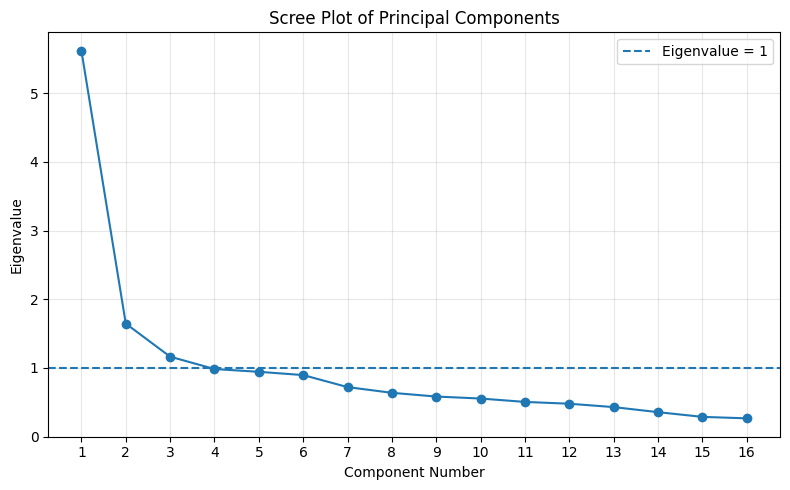

In [30]:
# Create the scree plot

plt.figure(figsize=(8, 5))

plt.plot(
    pca_variance_table["Component"],
    pca_variance_table["Eigenvalue"],
    marker="o"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Eigenvalue = 1"
)

plt.xlabel("Component Number")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot of Principal Components")
plt.xticks(range(1, 17))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4.4 Three-Component PCA Solution

In [31]:
# Perform PCA with three retained components

pca_3 = PCA(n_components=3)

pca_scores = pca_3.fit_transform(pca_scaled)

print("Explained variance ratio:")
print(pca_3.explained_variance_ratio_)

print("\nCumulative explained variance:")
print(pca_3.explained_variance_ratio_.cumsum())

Explained variance ratio:
[0.34953907 0.10239131 0.07241926]

Cumulative explained variance:
[0.34953907 0.45193038 0.52434964]


### 4.4.5 Rotated Component Matrix

Varimax rotation was applied to the three retained principal components to obtain a clearer interpretation of the underlying behavioural dimensions. The rotated component loadings indicate the strength of association between each questionnaire item and the extracted components.

In [32]:
# Varimax rotation of the three retained PCA components

# Start from the unrotated PCA loadings and apply orthogonal Varimax rotation.
base_pca = PCA(n_components=3)
base_scores = base_pca.fit_transform(pca_scaled)
base_loadings = base_pca.components_.T * np.sqrt(base_pca.explained_variance_)

def varimax(Phi, gamma=1.0, q=100, tol=1e-6):
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma / p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        )
        R = u @ vh
        d = s.sum()
        if d_old and d / d_old < 1 + tol:
            break
    return Phi @ R

loadings = pd.DataFrame(
    varimax(base_loadings),
    index=behavioural_cols,
    columns=["Component 1", "Component 2", "Component 3"]
)

loadings.round(3)

,Component 1,Component 2,Component 3
I regularly purchase products from retail stores or retail websites.,0.250,0.121,0.788
I shop for retail products several times each month.,0.156,0.105,0.774
I compare different products before making a purchase.,0.151,0.210,0.615
I usually plan my retail purchases before shopping.,0.269,0.096,0.585
I prefer to purchase products from the same retailers.,0.487,0.106,0.379
I prefer to purchase brands with which I am already familiar.,0.701,0.027,0.261
I usually choose my preferred brand even when other brands are available.,0.636,0.261,0.195
I intend to repurchase a brand when I am satisfied with it.,0.648,0.212,0.259
Discounts influence the products that I purchase.,0.567,0.261,0.266
Special offers encourage me to purchase additional products.,0.749,0.118,0.084


### Interpretation of Rotated Components

The rotated component matrix identifies three underlying behavioural dimensions. Component 1 is primarily associated with Brand Loyalty and Promotional Sensitivity, with strong loadings for familiarity with brands, preferred-brand choice, repurchase intention, discounts and special offers. Component 2 represents Product Category Variety, with high loadings for purchasing across different categories, diverse shopping baskets, trying new categories, and covering a wide range of needs. Component 3 primarily represents Shopping Behaviour, with strong loadings for regular purchasing, purchase frequency, product comparison, and purchase planning. Some items show cross-loadings, indicating overlap between related behavioural dimensions.

In [33]:
# Display only meaningful factor loadings (absolute loading >= 0.40)

loadings_highlighted = loadings.copy()

loadings_highlighted = loadings_highlighted.apply(
    lambda column: column.where(column.abs() >= 0.40)
)

loadings_highlighted.round(3)

,Component 1,Component 2,Component 3
I regularly purchase products from retail stores or retail websites.,NaN,NaN,0.788
I shop for retail products several times each month.,NaN,NaN,0.774
I compare different products before making a purchase.,NaN,NaN,0.615
I usually plan my retail purchases before shopping.,NaN,NaN,0.585
I prefer to purchase products from the same retailers.,0.487,NaN,NaN
I prefer to purchase brands with which I am already familiar.,0.701,NaN,NaN
I usually choose my preferred brand even when other brands are available.,0.636,NaN,NaN
I intend to repurchase a brand when I am satisfied with it.,0.648,NaN,NaN
Discounts influence the products that I purchase.,0.567,NaN,NaN
Special offers encourage me to purchase additional products.,0.749,NaN,NaN


## 4.5 K-Means Cluster Analysis

### 4.5.1 Preparation of Variables for K-Means Clustering

K-Means clustering was performed using the four composite behavioural measures: Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety. The variables were standardised using z-scores before clustering so that each behavioural measure contributed comparably to the clustering process.

In [34]:
# Standardise the four behavioural measures

cluster_data = numeric_data[behavioural_measures].copy()

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_data)

cluster_scaled_df = pd.DataFrame(
    cluster_scaled,
    columns=behavioural_measures
)

cluster_scaled_df.head()

,Shopping_Behavior,Brand_Loyalty,Promo_Senstivity,Product_Variety
0,1.695922,-0.186566,0.601927,0.294694
1,1.695922,1.788834,1.798395,1.110771
2,0.498801,0.208514,0.601927,0.294694
3,0.099760,0.208514,-0.594541,0.294694
4,0.897841,0.998674,1.000750,1.518810


In [35]:
# Perform K-Means clustering with three clusters

kmeans = KMeans(
    n_clusters=3,
    random_state=7,
    n_init=1,
    max_iter=300
)

cluster_labels = kmeans.fit_predict(cluster_scaled)

print("Number of iterations:", kmeans.n_iter_)
print("Inertia:", round(kmeans.inertia_, 3))

Number of iterations: 8
Inertia: 474.163


In [36]:
# Check the sizes of the three clusters

unique, counts = np.unique(cluster_labels, return_counts=True)

cluster_sizes = pd.DataFrame({
    "Python Cluster": unique,
    "Count": counts
})

cluster_sizes

,Python Cluster,Count
0,0,136
1,1,32
2,2,48


In [37]:
# Determine report cluster numbering from the behavioural profile
# Cluster 1 = highest overall behavioural score
# Cluster 2 = lowest overall behavioural score
# Cluster 3 = intermediate behavioural score

raw_cluster_profile = pd.DataFrame(cluster_scaled, columns=behavioural_measures)
raw_cluster_profile["Python Cluster"] = cluster_labels
raw_cluster_means = raw_cluster_profile.groupby("Python Cluster")[behavioural_measures].mean()
raw_cluster_means["Overall Mean"] = raw_cluster_means.mean(axis=1)

ordered_python_clusters = raw_cluster_means["Overall Mean"].sort_values(ascending=False).index.tolist()
cluster_mapping = {
    ordered_python_clusters[0]: 1,
    ordered_python_clusters[1]: 3,
    ordered_python_clusters[2]: 2
}

print("Python-to-report cluster mapping:", cluster_mapping)


Python-to-report cluster mapping: {2: 1, 0: 3, 1: 2}


In [38]:
# Map Python cluster labels to the report's cluster numbering

report_cluster_labels = pd.Series(cluster_labels).map(cluster_mapping)

# Add the report cluster number to the dataset
numeric_data["Cluster"] = report_cluster_labels.values

# Check the final cluster sizes
cluster_counts = (
    numeric_data["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts


,count
Cluster,
1,48
2,32
3,136


In [39]:
# Calculate the final standardized cluster centres

cluster_centres = (
    cluster_scaled_df
    .assign(Cluster=report_cluster_labels.values)
    .groupby("Cluster")[behavioural_measures]
    .mean()
)

cluster_centres.round(3)

,Shopping_Behavior,Brand_Loyalty,Promo_Senstivity,Product_Variety
Cluster,,,,
1,0.948,0.974,1.192,0.771
2,-1.509,-1.310,-1.280,-0.815
3,0.021,-0.036,-0.119,-0.080


### 4.5.2 Determining the Optimal Number of Clusters

The Elbow Method was used to examine the reduction in within-cluster inertia as the number of clusters increased. The resulting elbow curve was considered together with the silhouette analysis when selecting the final cluster solution.

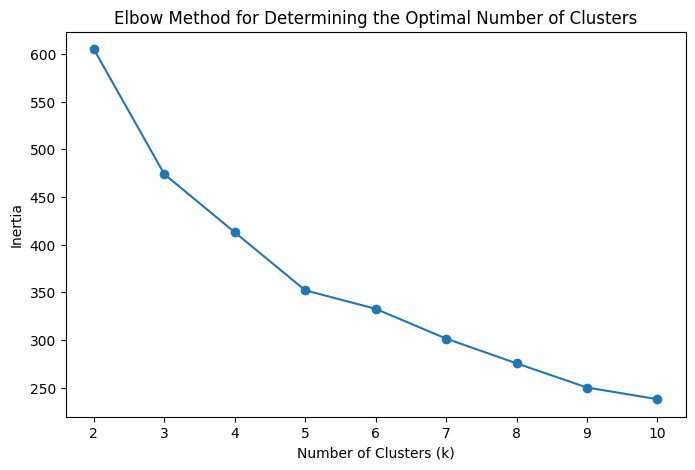

In [40]:
# Elbow Method for determining the optimal number of clusters

inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=7,
        n_init=10,
        max_iter=300
    )

    kmeans_test.fit(cluster_scaled)
    inertias.append(kmeans_test.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Determining the Optimal Number of Clusters")
plt.xticks(k_values)

plt.show()

### 4.5.3 Silhouette Analysis

Silhouette scores were calculated for cluster solutions from 2 to 10 clusters. The three-cluster solution produced the highest silhouette score (0.3118) among the tested solutions, supporting the selection of three clusters for the final K-Means segmentation.

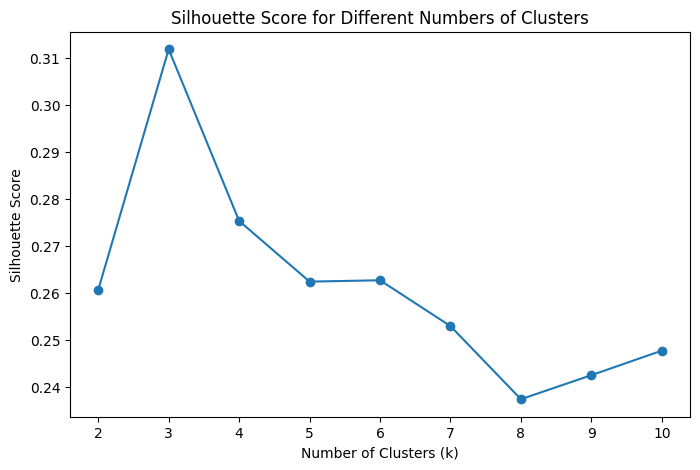

In [41]:
# Silhouette analysis for different numbers of clusters

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=7,
        n_init=10,
        max_iter=300
    )

    labels_test = kmeans_test.fit_predict(cluster_scaled)

    score = silhouette_score(
        cluster_scaled,
        labels_test
    )

    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xticks(range(2, 11))

plt.show()

In [42]:
# Display silhouette scores

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k = {k}: Silhouette Score = {score:.4f}")

k = 2: Silhouette Score = 0.2606
k = 3: Silhouette Score = 0.3118
k = 4: Silhouette Score = 0.2753
k = 5: Silhouette Score = 0.2624
k = 6: Silhouette Score = 0.2627
k = 7: Silhouette Score = 0.2529
k = 8: Silhouette Score = 0.2374
k = 9: Silhouette Score = 0.2425
k = 10: Silhouette Score = 0.2477


### 4.5.4 K-Means Clustering

In [43]:
# Perform K-Means clustering with three clusters

kmeans = KMeans(
    n_clusters=3,
    random_state=7,
    n_init=1,
    max_iter=300
)

cluster_labels = kmeans.fit_predict(cluster_scaled)

print("Number of iterations:", kmeans.n_iter_)
print("Inertia:", round(kmeans.inertia_, 3))

Number of iterations: 8
Inertia: 474.163


### 4.5.5 Visualisation of Customer Clusters

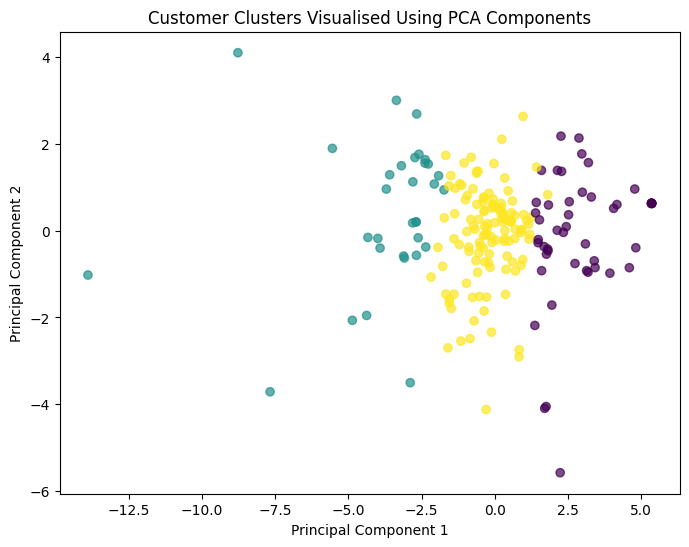

In [44]:
# Visualise the three customer clusters using the first two PCA components

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_scores[:, 0],
    pca_scores[:, 1],
    c=report_cluster_labels,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Clusters Visualised Using PCA Components")

plt.show()

### 4.5.6 Cluster Profile Visualisation

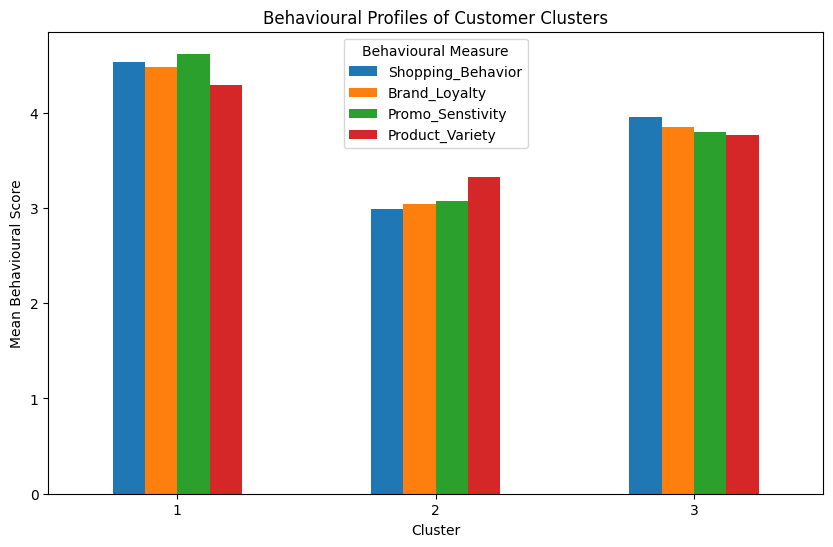

In [45]:
# Visualise the behavioural profiles of the three clusters

cluster_profile = numeric_data.groupby("Cluster")[
    [
        "Shopping_Behavior",
        "Brand_Loyalty",
        "Promo_Senstivity",
        "Product_Variety"
    ]
].mean()

cluster_profile.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Mean Behavioural Score")
plt.title("Behavioural Profiles of Customer Clusters")
plt.xticks(rotation=0)
plt.legend(title="Behavioural Measure")

plt.show()

## 4.6 Cluster Profiling and Comparison

### 4.6.1 Behavioural Profile of the Clusters

In [46]:
# Calculate the mean behavioural scores for each cluster

cluster_profile = (
    numeric_data
    .groupby("Cluster")[behavioural_measures]
    .agg(["count", "mean", "std"])
)

cluster_profile.round(4)

Shopping_Behavior                 Brand_Loyalty                  \
                    count    mean     std         count    mean     std   
Cluster                                                                   
1                      48  4.5312  0.4146            48  4.4844  0.4596   
2                      32  2.9922  0.7764            32  3.0391  0.7676   
3                     136  3.9504  0.3040           136  3.8456  0.3652   

        Promo_Senstivity                 Product_Variety                  
                   count    mean     std           count    mean     std  
Cluster                                                                   
1                     48  4.6198  0.3459              48  4.2917  0.6281  
2                     32  3.0703  0.5581              32  3.3203  0.7809  
3                    136  3.7978  0.3985             136  3.7702  0.4272

### 4.6.2 Welch's ANOVA

In [47]:
from scipy.stats import f_oneway

# Perform Welch's ANOVA for each behavioural measure

welch_results = []

for variable in behavioural_measures:
    groups = [
        numeric_data.loc[
            numeric_data["Cluster"] == cluster,
            variable
        ].dropna()
        for cluster in [1, 2, 3]
    ]

    result = f_oneway(*groups, equal_var=False)

    welch_results.append({
        "Variable": variable,
        "Welch F": result.statistic,
        "p-value": result.pvalue
    })

welch_table = pd.DataFrame(welch_results)

welch_table["Welch F"] = welch_table["Welch F"].round(3)
welch_table["p-value"] = welch_table["p-value"].apply(
    lambda p: "<0.001" if p < 0.001 else round(p, 3)
)

welch_table

,Variable,Welch F,p-value
0,Shopping_Behavior,67.279,<0.001
1,Brand_Loyalty,59.428,<0.001
2,Promo_Senstivity,137.470,<0.001
3,Product_Variety,20.756,<0.001


### 4.6.3 Games–Howell Post-hoc Comparisons

Games–Howell post-hoc comparisons were performed following Welch's ANOVA to identify which pairs of clusters differ significantly for each behavioural construct. This procedure is suitable when group variances and sample sizes may differ.


In [48]:
# Games–Howell post-hoc comparisons

from scipy.stats import studentized_range

games_howell_results = []

for variable in behavioural_measures:
    groups = {
        cluster: numeric_data.loc[numeric_data["Cluster"] == cluster, variable].dropna()
        for cluster in [1, 2, 3]
    }

    for i, j in [(1, 2), (1, 3), (2, 3)]:
        g1, g2 = groups[i], groups[j]
        n1, n2 = len(g1), len(g2)
        v1, v2 = g1.var(ddof=1), g2.var(ddof=1)
        mean_diff = g1.mean() - g2.mean()
        se = np.sqrt(v1 / n1 + v2 / n2)
        q = abs(mean_diff) / se
        df = (v1 / n1 + v2 / n2) ** 2 / (
            (v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1)
        )
        p_value = studentized_range.sf(q * np.sqrt(2), 3, df)

        games_howell_results.append({
            "Variable": variable,
            "A": i,
            "B": j,
            "Mean Difference": mean_diff,
            "p-value": p_value
        })

games_howell_table = pd.DataFrame(games_howell_results)
games_howell_table["Mean Difference"] = games_howell_table["Mean Difference"].round(4)
games_howell_table["p-value"] = games_howell_table["p-value"].apply(
    lambda p: "<0.001" if p < 0.001 else round(p, 3)
)

games_howell_table

,Variable,A,B,Mean Difference,p-value
0,Shopping_Behavior,1,2,1.5391,<0.001
1,Shopping_Behavior,1,3,0.5809,<0.001
2,Shopping_Behavior,2,3,-0.9582,<0.001
3,Brand_Loyalty,1,2,1.4453,<0.001
4,Brand_Loyalty,1,3,0.6388,<0.001
5,Brand_Loyalty,2,3,-0.8065,<0.001
6,Promo_Senstivity,1,2,1.5495,<0.001
7,Promo_Senstivity,1,3,0.8220,<0.001
8,Promo_Senstivity,2,3,-0.7275,<0.001
9,Product_Variety,1,2,0.9714,<0.001


### Interpretation of Games–Howell Post-hoc Comparisons

The Games–Howell results show statistically significant pairwise differences for all three cluster comparisons across all four behavioural constructs (p < .05). Cluster 1 differs significantly from Cluster 2 and Cluster 3 on Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Variety. Cluster 2 also differs significantly from Cluster 3 on all four constructs, including Product Variety (p = 0.009). These pairwise results support the conclusion that the three clusters represent meaningfully different behavioural profiles.

### 4.6.4 Kruskal–Wallis Tests

Kruskal–Wallis tests were also calculated as a non-parametric comparison of the four behavioural constructs across the three clusters. These results are reported separately from Welch's ANOVA because the two procedures make different assumptions. The Kruskal–Wallis results provide a robustness check of the cluster differences.


In [49]:
# Kruskal–Wallis tests for the four behavioural constructs

kruskal_results = []

for variable in behavioural_measures:
    groups = [
        numeric_data.loc[numeric_data["Cluster"] == cluster, variable].dropna()
        for cluster in [1, 2, 3]
    ]

    result = stats.kruskal(*groups)

    kruskal_results.append({
        "Variable": variable,
        "Kruskal-Wallis H": result.statistic,
        "p-value": result.pvalue
    })

kruskal_table = pd.DataFrame(kruskal_results)
kruskal_table["Kruskal-Wallis H"] = kruskal_table["Kruskal-Wallis H"].round(3)
kruskal_table["p-value"] = kruskal_table["p-value"].apply(
    lambda p: "<0.001" if p < 0.001 else round(p, 3)
)

kruskal_table


,Variable,Kruskal-Wallis H,p-value
0,Shopping_Behavior,109.382,<0.001
1,Brand_Loyalty,93.554,<0.001
2,Promo_Senstivity,123.597,<0.001
3,Product_Variety,55.547,<0.001


### Interpretation of Kruskal–Wallis Tests

The Kruskal–Wallis results are interpreted using a 5% significance level. Where p < .05, the test indicates that at least one cluster differs from another for the relevant behavioural construct. The Kruskal–Wallis test does not identify which specific pairs differ; the Games–Howell results above provide the pairwise comparisons.


### 4.6.5 Demographic Profile of the Clusters

The demographic characteristics of the three clusters were compared using cross-tabulations and Chi-square tests of independence. The analysis examined whether cluster membership was associated with age, gender, monthly income, education level, or employment status.

In [50]:
# Age distribution by cluster

age_cluster = pd.crosstab(
    data[data.columns[1]],
    numeric_data["Cluster"]
)

age_cluster

Cluster,1,2,3
What is your age?,,,
18-24 years,33,19,87
25-34 years,14,9,45
35-44 years,1,2,3
45-54 years,0,0,1
55 years or above,0,2,0


In [51]:
# Row percentages

age_cluster_percent = pd.crosstab(
    data[data.columns[1]],
    numeric_data["Cluster"],
    normalize="index"
) * 100

age_cluster_percent.round(1)

Cluster,1,2,3
What is your age?,,,
18-24 years,23.7,13.7,62.6
25-34 years,20.6,13.2,66.2
35-44 years,16.7,33.3,50.0
45-54 years,0.0,0.0,100.0
55 years or above,0.0,100.0,0.0


In [52]:
# Chi-square test: Age vs Cluster

from scipy.stats import chi2_contingency
age_table = pd.crosstab(
    data[data.columns[1]],
    numeric_data["Cluster"]
)

chi2_age, p_age, dof_age, expected_age = chi2_contingency(age_table)

print("Age vs Cluster")
print("Chi-square:", round(chi2_age, 3))
print("Degrees of freedom:", dof_age)
print("p-value:", p_age)

Age vs Cluster
Chi-square: 14.299
Degrees of freedom: 8
p-value: 0.074300811126515


### Interpretation

The Chi-square test indicates no statistically significant association between age group and cluster membership, χ²(8) = 14.299, p = 0.074. Therefore, the null hypothesis of independence is not rejected at the 5% significance level. The distribution of respondents across the three behavioural clusters does not differ significantly by age group in the updated dataset.

### 4.6.6 Gender Profile of the Clusters

In [53]:
# Gender distribution by cluster

gender_table = pd.crosstab(
    data[data.columns[2]],
    numeric_data["Cluster"]
)

gender_table

Cluster,1,2,3
What is your Gender?,,,
Female,13,16,69
Male,35,16,67


In [54]:
# Row percentages for gender by cluster

gender_percent = pd.crosstab(
    data[data.columns[2]],
    numeric_data["Cluster"],
    normalize="index"
) * 100

gender_percent.round(1)

Cluster,1,2,3
What is your Gender?,,,
Female,13.3,16.3,70.4
Male,29.7,13.6,56.8


In [55]:
# Chi-square test: Gender vs Cluster

chi2_gender, p_gender, dof_gender, expected_gender = chi2_contingency(
    gender_table
)

print("Gender vs Cluster")
print("Chi-square:", round(chi2_gender, 3))
print("Degrees of freedom:", dof_gender)
print("p-value:", p_gender)

Gender vs Cluster
Chi-square: 8.332
Degrees of freedom: 2
p-value: 0.015511636869085011


### Interpretation

The Chi-square test indicates a statistically significant association between gender and cluster membership, χ²(2) = 8.332, p = 0.016. This suggests that the distribution of male and female respondents differs across the three behavioural clusters in the updated dataset.

### 4.6.7 Income Profile of the Clusters

In [56]:
# Monthly income distribution by cluster

income_table = pd.crosstab(
    data[data.columns[3]],
    numeric_data["Cluster"]
)

income_table

Cluster,1,2,3
What is your approximate monthly income?,,,
"Less than £1,000",23,9,56
Prefer not to say,9,15,45
"£1,000–£1,999",8,0,20
"£2,000–£2,999",3,5,8
"£3,000–£3,999",1,1,2
"£4,000 or above",4,2,5


In [57]:
# Row percentages for income by cluster

income_percent = pd.crosstab(
    data[data.columns[3]],
    numeric_data["Cluster"],
    normalize="index"
) * 100

income_percent.round(1)

Cluster,1,2,3
What is your approximate monthly income?,,,
"Less than £1,000",26.1,10.2,63.6
Prefer not to say,13.0,21.7,65.2
"£1,000–£1,999",28.6,0.0,71.4
"£2,000–£2,999",18.8,31.2,50.0
"£3,000–£3,999",25.0,25.0,50.0
"£4,000 or above",36.4,18.2,45.5


In [58]:
# Chi-square test: Income vs Cluster

chi2_income, p_income, dof_income, expected_income = chi2_contingency(
    income_table
)

print("Income vs Cluster")
print("Chi-square:", round(chi2_income, 3))
print("Degrees of freedom:", dof_income)
print("p-value:", p_income)

Income vs Cluster
Chi-square: 17.184
Degrees of freedom: 10
p-value: 0.07038863516573808


In [59]:
# Check expected frequencies

expected_income_df = pd.DataFrame(
    expected_income,
    index=income_table.index,
    columns=income_table.columns
)

expected_income_df.round(2)

Cluster,1,2,3
What is your approximate monthly income?,,,
"Less than £1,000",19.56,13.04,55.41
Prefer not to say,15.33,10.22,43.44
"£1,000–£1,999",6.22,4.15,17.63
"£2,000–£2,999",3.56,2.37,10.07
"£3,000–£3,999",0.89,0.59,2.52
"£4,000 or above",2.44,1.63,6.93


### Interpretation

The Chi-square test indicates no statistically significant association between monthly income and cluster membership, χ²(10) = 17.184, p = 0.070. Therefore, the distribution of income categories does not differ significantly across the three behavioural clusters at the 5% significance level.

### 4.6.8 Education Profile of the Clusters

In [60]:
# Education distribution by cluster

education_table = pd.crosstab(
    data[data.columns[4]],
    numeric_data["Cluster"]
)

education_table

Cluster,1,2,3
What is your highest completed level of education?,,,
Bachelor’s degree,22,12,68
College or diploma,6,4,20
Doctoral degree or above,2,2,1
Master’s degree,16,7,27
Secondary school or below,2,7,20


In [61]:
# Row percentages for education by cluster

education_percent = pd.crosstab(
    data[data.columns[4]],
    numeric_data["Cluster"],
    normalize="index"
) * 100

education_percent.round(1)

Cluster,1,2,3
What is your highest completed level of education?,,,
Bachelor’s degree,21.6,11.8,66.7
College or diploma,20.0,13.3,66.7
Doctoral degree or above,40.0,40.0,20.0
Master’s degree,32.0,14.0,54.0
Secondary school or below,6.9,24.1,69.0


In [62]:
# Chi-square test: Education vs Cluster

chi2_education, p_education, dof_education, expected_education = chi2_contingency(
    education_table
)

print("Education vs Cluster")
print("Chi-square:", round(chi2_education, 3))
print("Degrees of freedom:", dof_education)
print("p-value:", p_education)

Education vs Cluster
Chi-square: 13.12
Degrees of freedom: 8
p-value: 0.10777039454341773


In [63]:
# Check expected frequencies

expected_education_df = pd.DataFrame(
    expected_education,
    index=education_table.index,
    columns=education_table.columns
)

expected_education_df.round(2)

Cluster,1,2,3
What is your highest completed level of education?,,,
Bachelor’s degree,22.67,15.11,64.22
College or diploma,6.67,4.44,18.89
Doctoral degree or above,1.11,0.74,3.15
Master’s degree,11.11,7.41,31.48
Secondary school or below,6.44,4.30,18.26


### Interpretation

The Chi-square test indicates no statistically significant association between education level and cluster membership, χ²(8) = 13.120, p = 0.108. Thus, there is insufficient evidence at the 5% level to conclude that cluster membership differs by education level.

### 4.6.9 Employment Profile of the Clusters

In [64]:
# Employment distribution by cluster

employment_table = pd.crosstab(
    data[data.columns[5]],
    numeric_data["Cluster"]
)

employment_table

Cluster,1,2,3
What is your current employment status?,,,
Employed full-time,21,8,40
Employed part-time,7,4,15
Retired,1,2,0
Self-employed,1,3,14
Student,14,12,53
Unemployed,4,3,14


In [65]:
# Row percentages for employment by cluster

employment_percent = pd.crosstab(
    data[data.columns[5]],
    numeric_data["Cluster"],
    normalize="index"
) * 100

employment_percent.round(1)

Cluster,1,2,3
What is your current employment status?,,,
Employed full-time,30.4,11.6,58.0
Employed part-time,26.9,15.4,57.7
Retired,33.3,66.7,0.0
Self-employed,5.6,16.7,77.8
Student,17.7,15.2,67.1
Unemployed,19.0,14.3,66.7


In [66]:
# Chi-square test: Employment vs Cluster

chi2_employment, p_employment, dof_employment, expected_employment = chi2_contingency(
    employment_table
)

print("Employment vs Cluster")
print("Chi-square:", round(chi2_employment, 3))
print("Degrees of freedom:", dof_employment)
print("p-value:", p_employment)

Employment vs Cluster
Chi-square: 14.735
Degrees of freedom: 10
p-value: 0.14204180422239424


In [67]:
# Check expected frequencies

expected_employment_df = pd.DataFrame(
    expected_employment,
    index=employment_table.index,
    columns=employment_table.columns
)

expected_employment_df.round(2)

Cluster,1,2,3
What is your current employment status?,,,
Employed full-time,15.33,10.22,43.44
Employed part-time,5.78,3.85,16.37
Retired,0.67,0.44,1.89
Self-employed,4.00,2.67,11.33
Student,17.56,11.70,49.74
Unemployed,4.67,3.11,13.22


### Interpretation

The Chi-square test indicates no statistically significant association between employment status and cluster membership, χ²(10) = 14.735, p = 0.142. Therefore, employment status does not show a statistically significant relationship with cluster membership in the updated dataset.

### 4.6.10 Shopping Channel Profile

In [68]:
# Display the five shopping-channel questions

channel_cols = data.columns[22:27]

for i, column in enumerate(channel_cols, 1):
    print(f"{i}. {column}")

1. Which shopping channel do you generally prefer?
2. Which shopping channel have you used most frequently during the past three months?
3. Which channel do you prefer when researching and comparing products?
4. Which channel do you prefer when purchasing routine or frequently used products?
5. Which channel do you prefer when purchasing expensive or important products?


In [69]:
# Display the available responses for each channel question

for column in channel_cols:
    print("\n", column)
    print(data[column].value_counts())


 Which shopping channel do you generally prefer?
Which shopping channel do you generally prefer?
Both equally                111
Physical retail stores       49
Online shopping              44
No particular preference     12
Name: count, dtype: int64

 Which shopping channel have you used most frequently during the past three months?
Which shopping channel have you used most frequently during the past three months?
Both equally                            85
Physical retail stores                  71
Online shopping                         51
I have not made any retail purchases     9
Name: count, dtype: int64

 Which channel do you prefer when researching and comparing products?
Which channel do you prefer when researching and comparing products?
Online channels                    91
Both online and physical stores    73
Physical retail stores             43
No particular preference            9
Name: count, dtype: int64

 Which channel do you prefer when purchasing routine or frequen

In [70]:
# Cross-tabulations of shopping-channel preferences by cluster

for i, column in enumerate(channel_cols, 1):
    print("\n" + "=" * 80)
    print(f"CHANNEL QUESTION {i}")
    print(column)
    print("=" * 80)

    channel_table = pd.crosstab(
        data[column],
        numeric_data["Cluster"]
    )

    display(channel_table)


CHANNEL QUESTION 1
Which shopping channel do you generally prefer?


Cluster,1,2,3
Which shopping channel do you generally prefer?,,,
Both equally,20,15,76
No particular preference,2,6,4
Online shopping,17,6,21
Physical retail stores,9,5,35



CHANNEL QUESTION 2
Which shopping channel have you used most frequently during the past three months?


Cluster,1,2,3
Which shopping channel have you used most frequently during the past three months?,,,
Both equally,17,12,56
I have not made any retail purchases,2,5,2
Online shopping,17,6,28
Physical retail stores,12,9,50



CHANNEL QUESTION 3
Which channel do you prefer when researching and comparing products?


Cluster,1,2,3
Which channel do you prefer when researching and comparing products?,,,
Both online and physical stores,19,11,43
No particular preference,0,5,4
Online channels,22,11,58
Physical retail stores,7,5,31



CHANNEL QUESTION 4
Which channel do you prefer when purchasing routine or frequently used products?


Cluster,1,2,3
Which channel do you prefer when purchasing routine or frequently used products?,,,
Both equally,17,15,43
Not applicable,1,5,6
Online shopping,20,5,44
Physical retail stores,10,7,43



CHANNEL QUESTION 5
Which channel do you prefer when purchasing expensive or important products?


Cluster,1,2,3
Which channel do you prefer when purchasing expensive or important products?,,,
Both equally,13,13,41
Not applicable,0,4,3
Online shopping,13,5,37
Physical retail stores,21,10,53


In [71]:
# Chi-square tests for shopping-channel variables

channel_chi_results = []

for column in channel_cols:

    channel_table = pd.crosstab(
        data[column],
        numeric_data["Cluster"]
    )

    chi2, p, dof, expected = chi2_contingency(channel_table)

    channel_chi_results.append({
        "Variable": column,
        "Chi-square": chi2,
        "df": dof,
        "p-value": p
    })

channel_chi_table = pd.DataFrame(channel_chi_results)

channel_chi_table["Chi-square"] = channel_chi_table["Chi-square"].round(3)
channel_chi_table["p-value"] = channel_chi_table["p-value"].round(6)

channel_chi_table

,Variable,Chi-square,df,p-value
0,Which shopping channel do you generally prefer?,21.998,6,0.001212
1,Which shopping channel have you used most freq...,18.219,6,0.005708
2,Which channel do you prefer when researching a...,15.413,6,0.017279
3,Which channel do you prefer when purchasing ro...,14.999,6,0.020261
4,Which channel do you prefer when purchasing ex...,13.748,6,0.032577


### Interpretation

The Chi-square tests indicate statistically significant associations between cluster membership and all five shopping-channel variables at the 5% significance level. General shopping-channel preference was significant, χ²(6) = 21.998, p = 0.001. The channel used most frequently during the past three months was also significant, χ²(6) = 18.219, p = 0.006. Significant associations were additionally observed for product research and comparison, χ²(6) = 15.413, p = 0.017, routine product purchases, χ²(6) = 14.999, p = 0.020, and expensive or important product purchases, χ²(6) = 13.748, p = 0.033. These findings indicate that the behavioural clusters differ in their shopping-channel preferences and usage patterns.

## 4.7 Overall Cluster Summary

### Cluster Characteristics

The K-Means analysis identified three distinct behavioural customer segments among the 216 respondents in the updated dataset.

**Cluster 1 – Highly Engaged / Promotion Responsive (n = 48):** This cluster records the highest mean scores across all four behavioural constructs: Shopping Behaviour (4.531), Brand Loyalty (4.484), Promotional Sensitivity (4.620), and Product Variety (4.292). The profile indicates comparatively strong engagement, brand loyalty, responsiveness to promotions, and broad product-category involvement.

**Cluster 2 – Lower Engagement (n = 32):** This cluster records the lowest mean scores for Shopping Behaviour (2.992), Brand Loyalty (3.039), and Promotional Sensitivity (3.070), with Product Variety also comparatively lower (3.320). It represents respondents with relatively lower levels of the measured behavioural characteristics.

**Cluster 3 – Mainstream (n = 136):** This is the largest cluster and has intermediate mean scores for Shopping Behaviour (3.950), Brand Loyalty (3.846), Promotional Sensitivity (3.798), and Product Variety (3.770). It represents the mainstream behavioural profile of the sample.

Overall, the three-cluster solution provides a clear behavioural segmentation of the updated sample, with Cluster 1 representing the most engaged profile, Cluster 2 the least engaged profile, and Cluster 3 an intermediate mainstream profile.